Reading 2 fields across snapshots...
Successfully saved plot: evol_vrms_Tmax.png


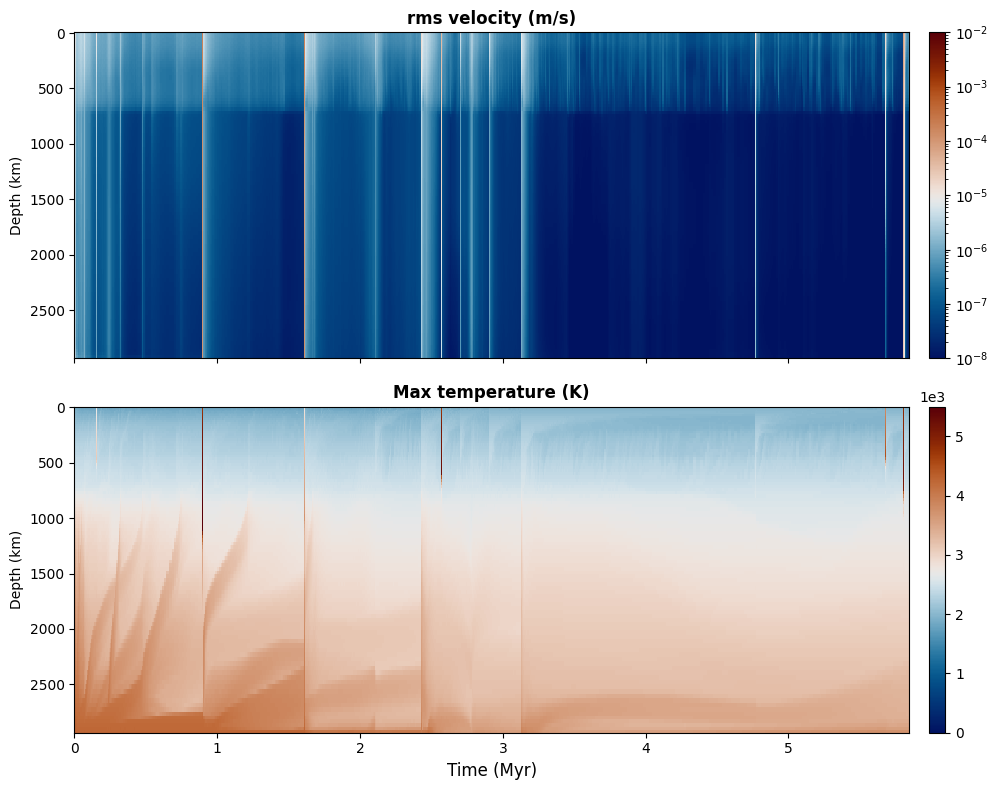

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from stagpy.stagyydata import StagyyData
from matplotlib.colors import LogNorm, Normalize
from matplotlib.ticker import LogFormatterExponent, LogFormatterSciNotation

# Try to import Crameri colormaps; fallback if not installed
try:
    from cmcrameri import cm
    HAS_CRAMERI = True
except ImportError:
    HAS_CRAMERI = False

# --- FULL LIST OF RPROF PARAMETERS ---
# Use these strings in 'field_to_plot' to change the data being visualized.
ALL_RPROF_FIELDS = [
    "r",            # Radial coordinate
    "Tmean",        # Temperature
    "Tmin",         # Min temperature
    "Tmax",         # Max temperature
    "vrms",         # rms velocity
    "vmin",         # Min velocity
    "vmax",         # Max velocity
    "vzabs",        # Radial velocity
    "vzmin",        # Min radial velocity
    "vzmax",        # Max radial velocity
    "vhrms",        # Horizontal velocity
    "vhmin",        # Min horiz velocity
    "vhmax",        # Max horiz velocity
    "etalog",       # Viscosity
    "etamin",       # Min viscosity
    "etamax",       # Max viscosity
    "elog",         # Strain rate
    "emin",         # Min strain rate
    "emax",         # Max strain rate
    "slog",         # Stress
    "smin",         # Min stress
    "smax",         # Max stress
    "whrms",        # Horizontal vorticity
    "whmin",        # Min horiz vorticity
    "whmax",        # Max horiz vorticity
    "wzrms",        # Radial vorticity
    "wzmin",        # Min radial vorticity
    "wzmax",        # Max radial vorticity
    "drms",         # Divergence
    "dmin",         # Min divergence
    "dmax",         # Max divergence
    "enadv",        # Advection
    "endiff",       # Diffusion
    "enradh",       # Radiogenic heating
    "enviscdiss",   # Viscous dissipation
    "enadiabh",     # Adiabatic heating
    "bsmean",       # Basalt content
    "bsmin",        # Min basalt content
    "bsmax",        # Max basalt content
    "rhomean",      # Density
    "rhomin",       # Min density
    "rhomax",       # Max density
    "airmean",      # Air
    "airmin",       # Min air
    "airmax",       # Max air
    "primmean",     # Primordial
    "primmin",      # Min primordial
    "primmax",      # Max primordial
    "ccmean",       # Continental crust
    "ccmin",        # Min continental crust
    "ccmax",        # Max continental crust
    "fmeltmean",    # Melt fraction
    "fmeltmin",     # Min melt fraction
    "fmeltmax",     # Max melt fraction
    "metalmean",    # Metal
    "metalmin",     # Min metal
    "metalmax",     # Max metal
    "gsmean",       # Grain size
    "gsmin",        # Min grain size
    "gsmax",        # Max grain
    "viscdisslog",  # Viscous dissipation
    "viscdissmin",  # Min visc dissipation
    "viscdissmax",  # Max visc dissipation
    "advtot",       # Advection
    "advdesc",      # Downward advection
    "advasc",       # Upward advection
    "tcondmean",    # Conductivity
    "tcondmin",     # Min conductivity
    "tcondmax",     # Max conductivity
    "impmean",      # Impactor fraction
    "impmin",       # Min impactor fraction
    "impmax",       # Max impactor fraction
    "hzmean",       # Harzburgite fraction
    "hzmin",        # Min harzburgite fraction
    "hzmax",        # Max harzburgite fraction
    "TTGmean",      # TTG fraction
    "TTGmin",       # Min TTG fraction
    "TTGmax",       # Max TTG fraction
    "edismean",     # Dislocation creep fraction
    "edismin",      # Min dislocation creep fraction
    "edismax",      # Max dislocation creep fraction
    "egbsmean",     # Grain boundary sliding fraction
    "egbsmin",      # Min grain boundary sliding fraction
    "egbsmax",      # Max grain boundary sliding fraction
    "ePeimean",     # Peierls creep fraction
    "ePeimin",      # Min Peierls creep fraction
    "ePeimax",      # Max Peierls creep fraction
    "eplamean",     # Plasticity fraction
    "eplamin",      # Min plasticity fraction
    "eplamax",      # Max plasticity fraction
    "dr",           # Cell thicknesses
    "diff",         # Diffusion flux
    "diffs",        # Scaled diffusion flux
    "advts",        # Scaled advection flux
    "advds",        # Scaled downward advection flux
    "advas",        # Scaled upward advection flux
    "energy"        # Total heat flux
]

# --- USER CONFIGURATION ---
data_path = Path("/media/aritro/f522493b-003a-404d-a839-3e0925c674b6/Aritro/StagYY/runs/festus/venus_imp5/archive/")
fields_to_plot = ["vrms", "Tmax"]   

FIELD_LIMITS = {
    "Tmax": (0, 5500),
    "vmax": (1e-6, 1.2e-3),
    "vrms": (1e-8, 1e-2), 
    "fmeltmax": (0, 1.0),
    "etalog": (1e18, 1e24),
}

sample_step = 1  # use 1 for all steps, 10 for every ten steps, etc.
sdat = StagyyData(data_path)

# --- COLOURMAP OPTIONS ---
USE_CRAMERI = True
SEQUENTIAL_MAP = "vik"  # Used for T, vrms, viscosity, etc.
DIVERGING_MAP  = "roma"     # Used for vz, vh, divergence, etc.

# --- DATA COLLECTION ---
times, depths = [], None
plot_data = {f: [] for f in fields_to_plot}
field_meta = {f: {"title": "", "log": False} for f in fields_to_plot}

print(f"Reading {len(fields_to_plot)} fields across snapshots...")

for snap in sdat.snaps[::sample_step]:
    try:
        times.append(snap.time / (3600 * 24 * 365.25 * 1e6)) 
        
        for field in fields_to_plot:
            rprof = snap.rprofs[field]
            plot_data[field].append(rprof.values)
            
            if not field_meta[field]["title"]:
                desc, unit = rprof.meta.description, rprof.meta.dim
                field_meta[field]["title"] = f"{desc} ({unit})" if unit else desc
                
                if any(k in field.lower() for k in ["log", "eta", "slog", "visc", "vrms", "vmax", "vmin"]):
                    field_meta[field]["log"] = True

            if depths is None:
                r_surf = np.max(rprof.rad)
                depths = (r_surf - rprof.rad) / 1e3 
                
    except (KeyError, AttributeError):
        continue

# --- PLOTTING ---
fig, axes = plt.subplots(len(fields_to_plot), 1, 
                         figsize=(11, 4 * len(fields_to_plot)), 
                         sharex=True, squeeze=False)

for i, field in enumerate(fields_to_plot):
    ax = axes[i, 0]
    data_matrix = np.array(plot_data[field]).T
    
    vmin, vmax = FIELD_LIMITS.get(field, (None, None))
    
    if field_meta[field]["log"]:
        data_matrix = np.clip(data_matrix, 1e-35, None) 
        if vmin is None or vmin <= 0: 
            vmin = np.nanmin(data_matrix[data_matrix > 0])
        if vmax is None: 
            vmax = np.nanmax(data_matrix)
        norm = LogNorm(vmin=vmin, vmax=vmax)
    else:
        norm = Normalize(vmin=vmin, vmax=vmax)

    # Automatically determine if field is diverging or sequential
    is_diverging = any(k in field.lower() for k in ["vz", "vh", "drms", "adv"])

    if USE_CRAMERI and HAS_CRAMERI:
        if is_diverging:
            cmap = getattr(cm, DIVERGING_MAP)
        else:
            cmap = getattr(cm, SEQUENTIAL_MAP)
    else:
        # Fallback to standard Matplotlib defaults
        cmap = 'RdBu_r' if is_diverging else 'magma'

    im = ax.pcolormesh(np.array(times), depths, data_matrix, 
                       shading='auto', cmap=cmap, norm=norm)
    
    ax.set_title(field_meta[field]["title"], fontweight='bold', fontsize=12)
    ax.set_ylabel("Depth (km)", fontsize=10)
    ax.invert_yaxis() 
    
    if field_meta[field]["log"]:
        formatter = LogFormatterSciNotation(base=10, labelOnlyBase=False)
        cbar = plt.colorbar(im, ax=ax, pad=0.02, format=formatter)
    else:
        cbar = plt.colorbar(im, ax=ax, pad=0.02)
        if (vmax and (vmax > 1000 or vmax < 0.01)):
            cbar.formatter.set_powerlimits((0, 0))

axes[-1, 0].set_xlabel("Time (Myr)", fontsize=12)

plt.tight_layout()

save_name = f"evol_{'_'.join(fields_to_plot)}.png"
fig.savefig(save_name, dpi=300)
print(f"Successfully saved plot: {save_name}")
plt.show()